In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
OUTPATH = "../../output/results-summary-090624/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


## when measuring how ideologically sorted an individual is in a belief system, we need to take into account two components

In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
# internet access
anes_all["it_access"] = anes_all["it_access"].replace(5, 0)
anes_all["it_access"] = anes_all["it_access"].replace(9, np.NaN)
anes_all.head()


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_blacks,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,4.0,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,4.0,7.0,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,1.0,6.0,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,5.0,4.0,1.0,0.0,5.0,NaN,5.0,3.0,0.6005,-5.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,4.0,5.0,1.0,0.0,5.0,NaN,6.0,7.0,1.9270,70.0


In [3]:
anes_all.columns

Index(['year', 'gov_health', 'guar_jobs', 'us_isolate', 'aid_black', 'abort',
       'spend_serv', 'def_spend', 'aff_act_1', 'aff_act_2', 'gay_discr',
       'immigrat', 'spend_poor', 'spend_child', 'spend_crime', 'spend_school',
       'spend_welfare', 'spend_env', 'spend_socsec', 'black_fairjob',
       'import_lim', 'death_pen', 'gun_own', 'def_spend_D', 'aid_black_D',
       'gov_health_D', 'spend_serv_D', 'guar_jobs_D', 'lib_con_D', 'abort_D',
       'def_spend_R', 'aid_black_R', 'gov_health_R', 'spend_serv_R',
       'guar_jobs_R', 'lib_con_R', 'abort_R', 'lib_con', 'pid', 'egal_1',
       'egal_2', 'auth_1', 'auth_2', 'auth_3', 'auth_4', 'rac_res_1',
       'rac_res_2', 'rac_res_3', 'rac_res_4', 'penalty_favopp', 'ft_jews',
       'ft_blacks', 'ft_whites', 'ft_bis', 'ft_lab', 'ft_lib', 'ft_con',
       'ft_his', 'ft_dem', 'ft_poor', 'ft_rep', 'ft_asian', 'ft_congr',
       'ft_gay', 'ft_immigr', 'ft_chrfund', 'ft_fem', 'ft_mus', 'ft_chr',
       'hw_whites', 'hw_blacks', 'hw_his

## code the partisan response

In [4]:
# 1. Strong Democrat
# 2. Weak Democrat
# 3. Independent - Democrat
# 4. Independent - Independent
# 5. Independent - Republican
# 6. Weak Republican
# 7. Strong Republican

PARTISAN_LABEL_CATG = {
    1: -1, 2: -1, 3: -1, 
    4: 0,
    5: 1, 6: 1, 7: 1,
}

anes_all["dem_rep_3"] = anes_all["dem_rep"].map(lambda x: PARTISAN_LABEL_CATG[x] if not np.isnan(x) else np.NaN)
anes_all = anes_all[anes_all["dem_rep_3"].notna()]
print("# of NaN:", len(anes_all[anes_all["dem_rep_3"].isna()]))
print("# of independents:", len(anes_all[anes_all["dem_rep_3"]==0]))
# anes_all["ft_dict"] = anes_all.apply(lambda x: {"DEM": x["ft_dem"], "REP": x["ft_rep"]}, axis=1)

# of NaN: 0
# of independents: 2948


> Affective polarization was measured as the difference in feeling thermometer scores towards a person’s in-party and their out-party. (Lelkes 2018)

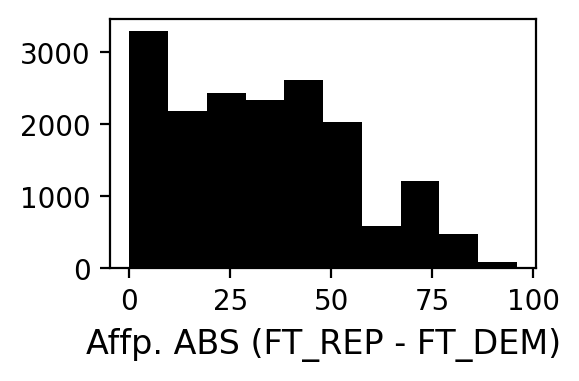

In [5]:
# an easy shortcut for affective polarization is just to get the absolute difference
anes_all["ft_rep_net_abs"] = anes_all["ft_rep_net"].map(lambda x: abs(x))

fig,ax = plt.subplots(figsize=(3,2))
plt.hist(anes_all["ft_rep_net_abs"], color="black", bins=10)
plt.xlabel("Affp. ABS (FT_REP - FT_DEM)", fontsize=12)
plt.tight_layout()


In [6]:
NODE_COLS = [
    # "spend_serv", "gov_health", "guar_jobs", "aff_act_2", "abort",
    # "immigrat", "gun_own", "spend_school", "spend_crime", "spend_welfare",
    # "spend_poor", "penalty_favopp", "gay_discr",
    "gov_health", "guar_jobs", "abort", "aid_black", "spend_serv"
    # "left_right", "lbrl_cnsv"
]

COV_COLS = ["ft_rep_net"]

In [7]:
RESIN_DICT = {}
NEUTRAL_VAL_DICT = {}
for year in YEARS:
    print("processing:", year)
    anes_year = anes_all[anes_all["year"]==year].copy()
    anes_year = anes_year[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.get_item_size()
    resin.set_edge_distance()
    RESIN_DICT[year] = resin
    NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

processing: 2000
processing: 2004
processing: 2008
processing: 2012
processing: 2016
processing: 2020


In [8]:
YEAR_RESPONSE_DICT = {}

for year in YEARS:
    YEAR_RESPONSE_DICT[year] = anes_all[anes_all["year"]==year].to_dict("index")

In [8]:
def get_density_weighted(g):
    s = np.sum([e[2]["weight"] for e in g.edges(data=True)])
    n = len(g.nodes())
    denm = n*(n-1)/2
    return s/denm 

def prepare_respondent_df(year, issues=NODE_COLS):
    resin = RESIN_DICT[year]
    response_dict = YEAR_RESPONSE_DICT[year]
    g = resin.g 
    
    respondent_df = pd.DataFrame()
    sort_ls = []
    affp_ls = []
    part_ls = []
    for _, response in response_dict.items():
        sub_nodes = [f"{x}:{response[x]}" for x in issues if not np.isnan(response[x])]
        subg = g.subgraph(sub_nodes) # get subgraph 
        sort_ls.append(get_density_weighted(subg))
        affp_ls.append(response["ft_rep_net_abs"])
        part_ls.append(response["dem_rep_3"])
    respondent_df["sort"] = sort_ls 
    respondent_df["affp"] = affp_ls
    respondent_df["part"] = part_ls
    respondent_df.dropna(inplace=True)
    return respondent_df


In [9]:
respondent_df_all = pd.DataFrame()
for year in YEARS:
    print(year, "preparing repondent df")
    rdf = prepare_respondent_df(year)
    rdf["year"] = year
    respondent_df_all = pd.concat([rdf, respondent_df_all])
    print("# of res:", len(rdf))

2000 preparing repondent df
# of res: 871
2004 preparing repondent df
# of res: 1011
2008 preparing repondent df
# of res: 925
2012 preparing repondent df


/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm


# of res: 4445
2016 preparing repondent df
# of res: 3198
2020 preparing repondent df


/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_39174/2716057293.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm


# of res: 4872


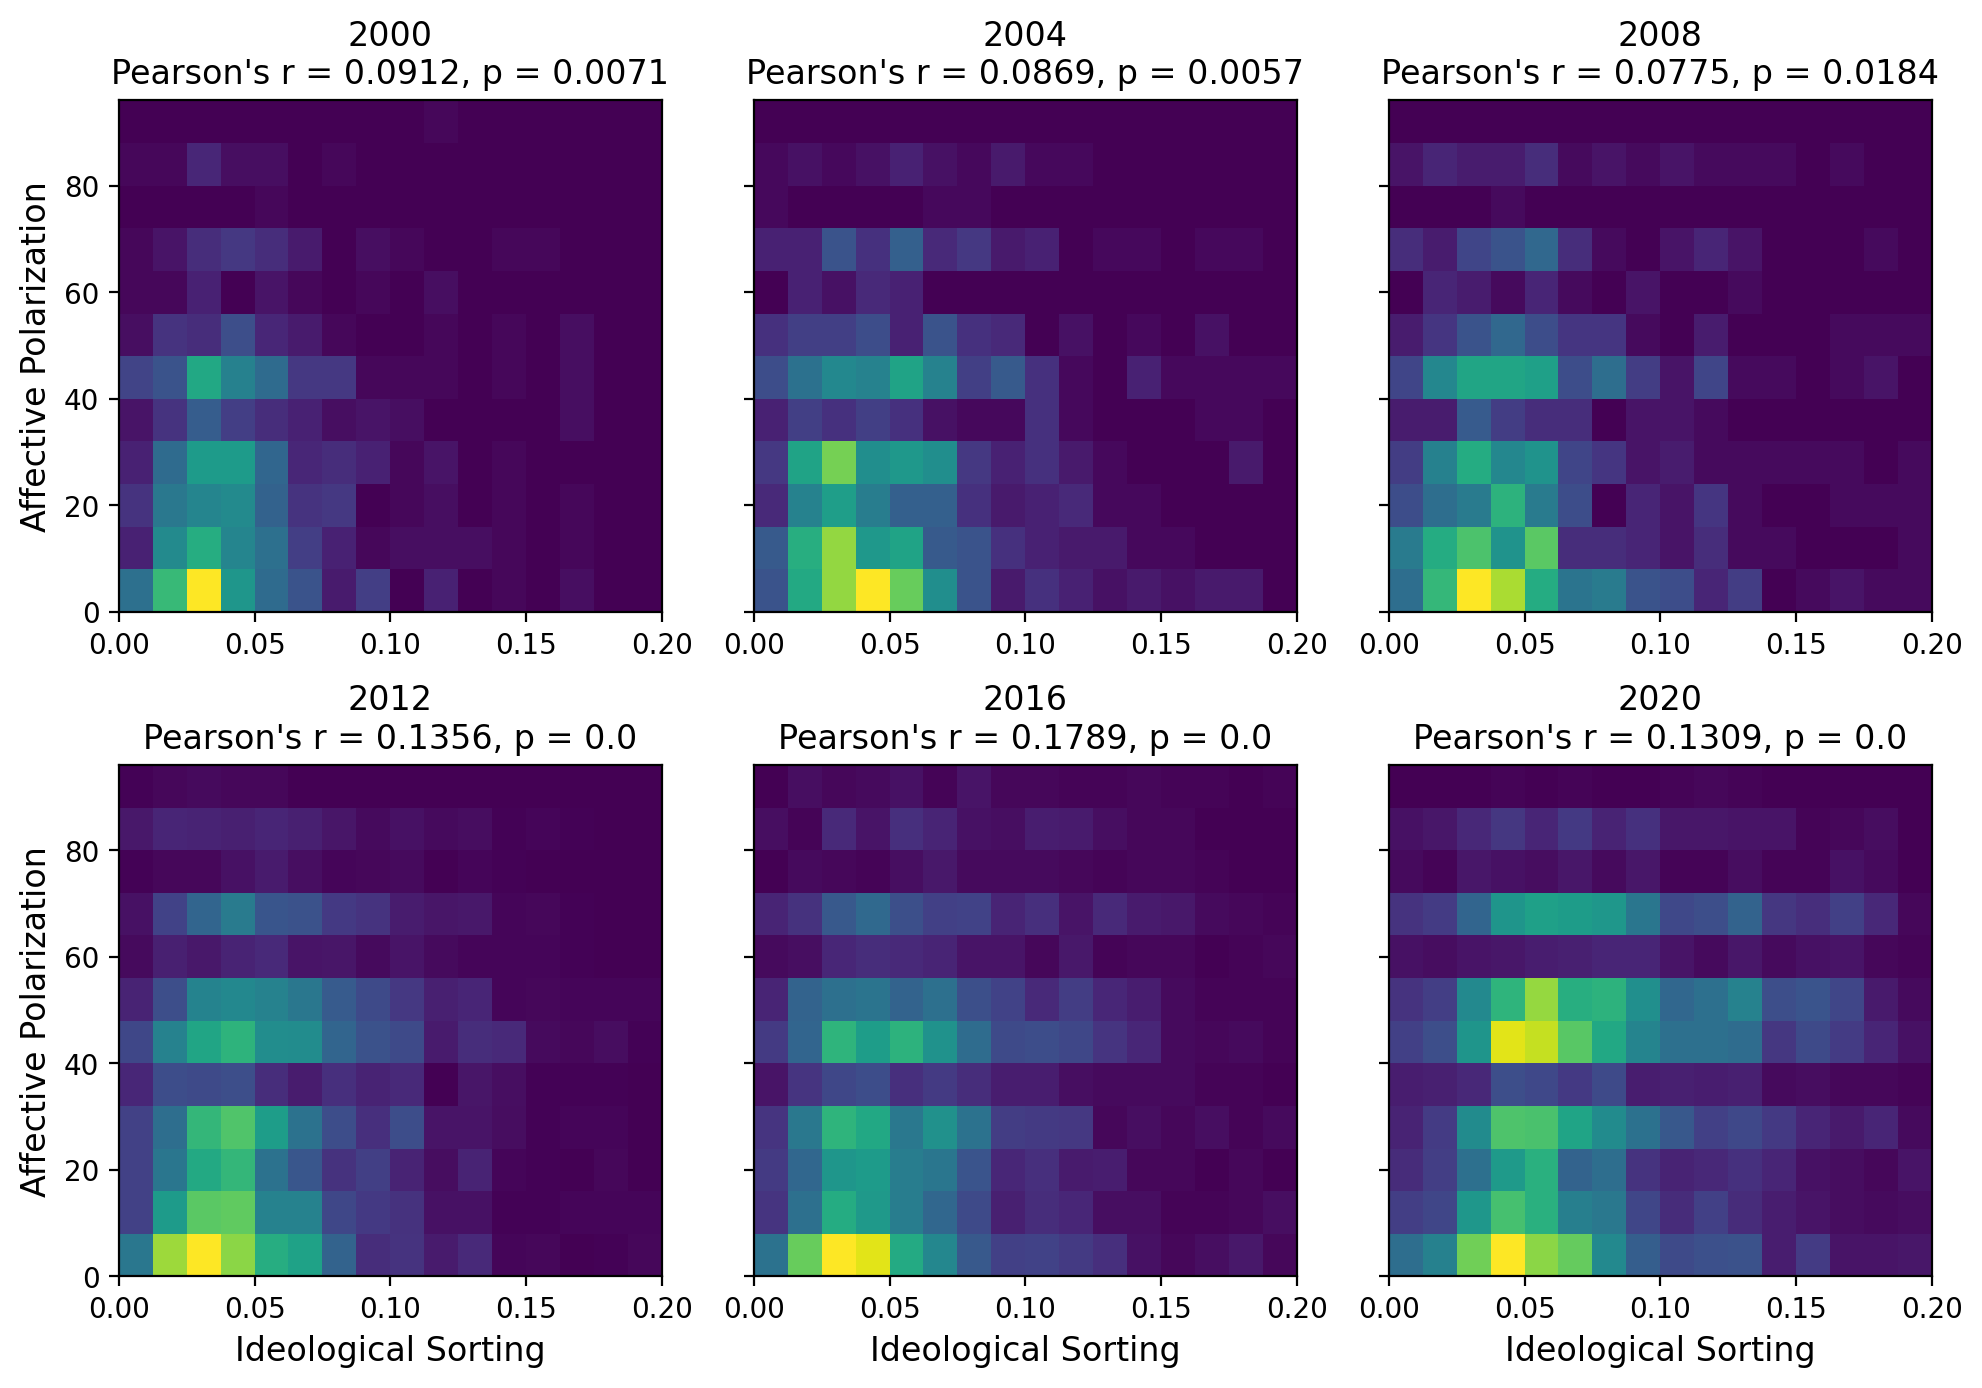

In [10]:
from scipy.stats import pearsonr
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,7), sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    rdf = respondent_df_all[respondent_df_all["year"]==year]
    # ax[i].scatter(rdf["sort"], rdf["affp"], marker="+", color="black")
    ax[i].hist2d(rdf["sort"], rdf["affp"], bins=[np.arange(0, .225, .0125), np.arange(0, 100, 8)])
    r,p = pearsonr(rdf["sort"], rdf["affp"])
    ax[i].set_xlim(0,0.20)
    ax[i].set_title(f"{year}\nPearson's r = {round(r,4)}, p = {round(p,4)}", fontsize=12)
    if i in [0,3]:
        ax[i].set_ylabel("Affective Polarization", fontsize=12)
    if i > 2:
        ax[i].set_xlabel("Ideological Sorting", fontsize=12)
plt.tight_layout()
# plt.savefig(OUTPATH + "sort_affp_hist2d_2000_2020.png", dpi=300, bbox_inches="tight")

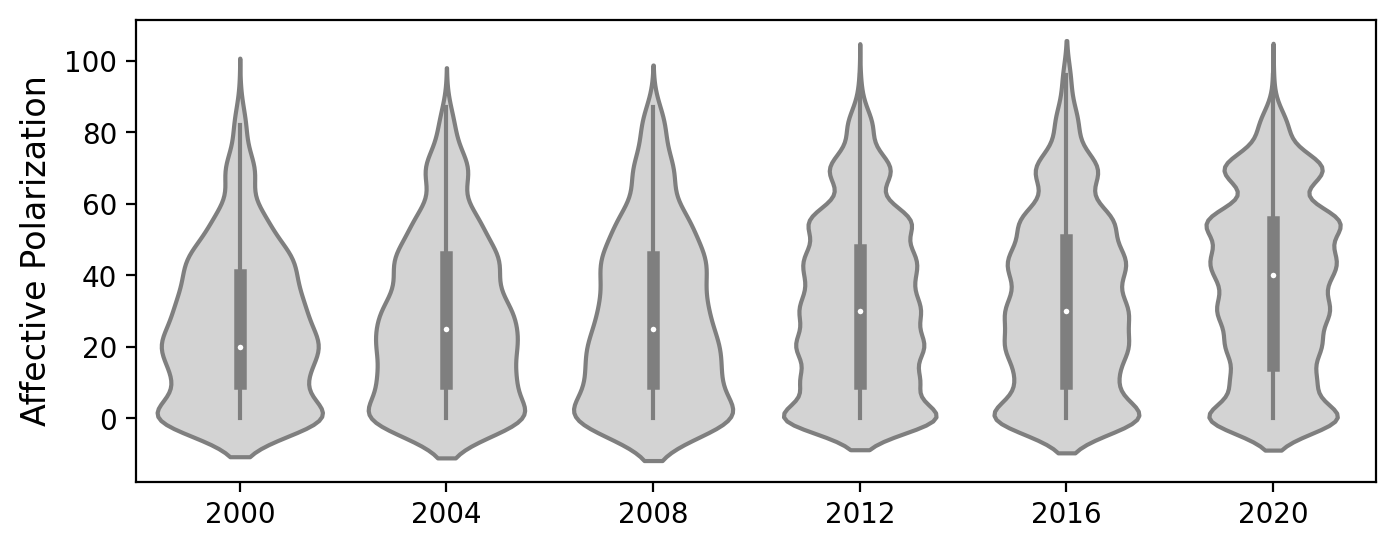

In [11]:
fig,ax = plt.subplots(figsize=(8,3))
ax.set_xticks(range(1,7), YEARS)
sns.violinplot(x="year", y="affp", data = respondent_df_all, color="lightgrey", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Affective Polarization", fontsize=12)
plt.savefig(OUTPATH + "affp_years.png", dpi=300, bbox_inches="tight")

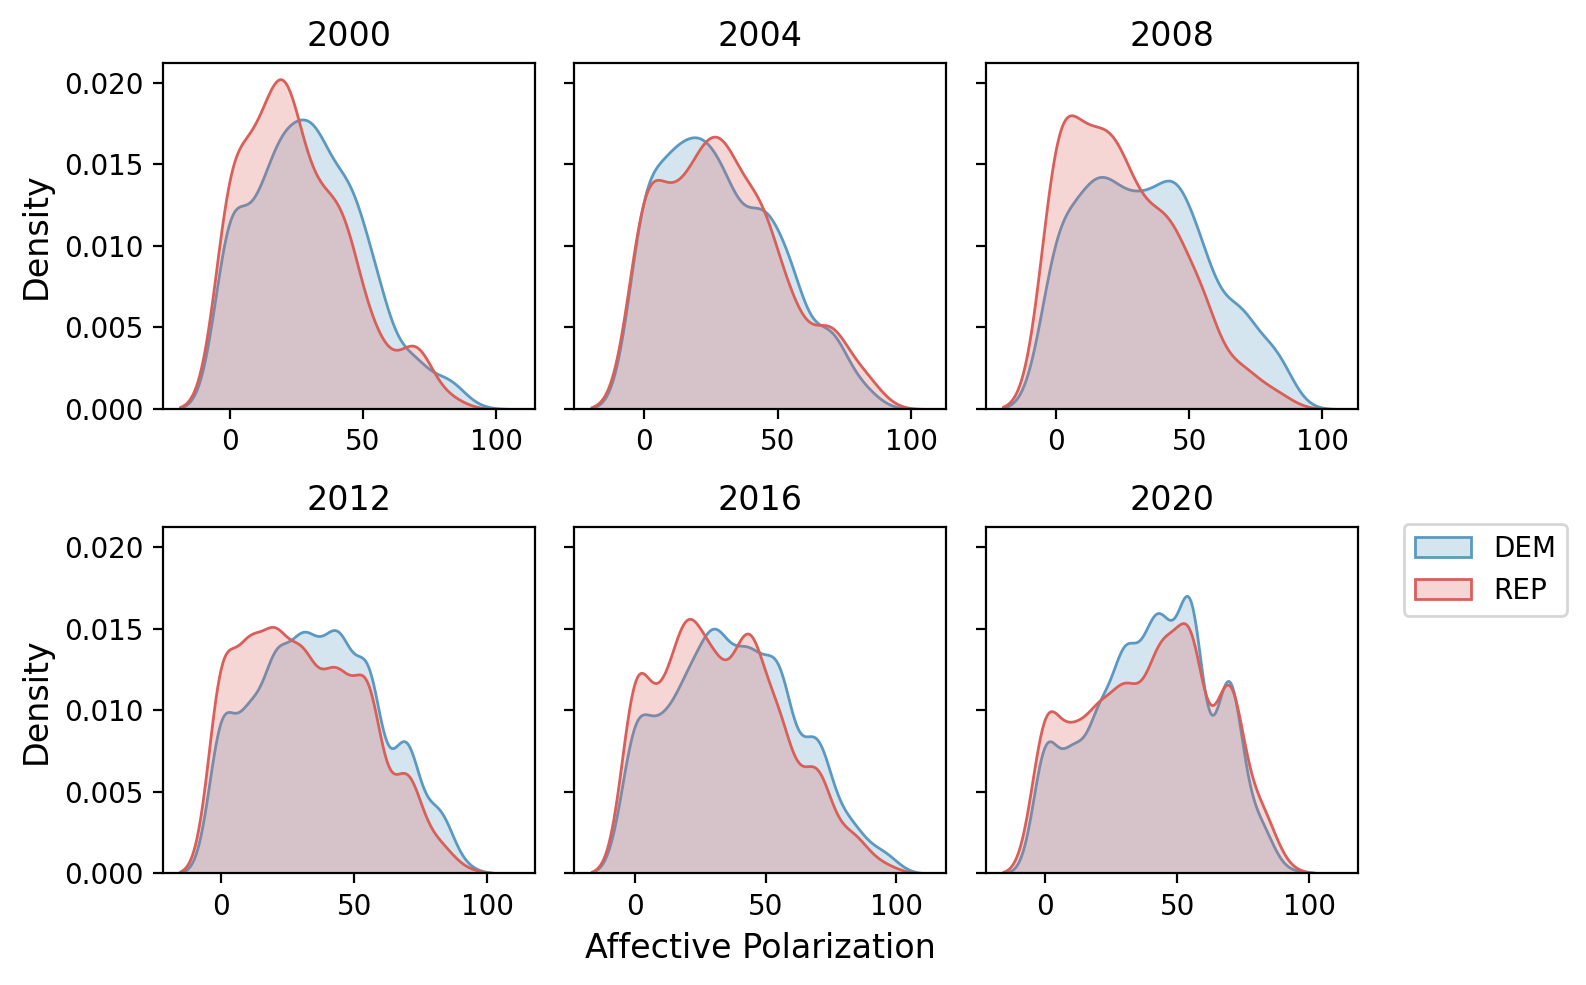

In [12]:
import seaborn as sns
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(8,5), sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    rdf = respondent_df_all[respondent_df_all["year"]==year]
    dem_rdf = rdf[rdf["part"]==-1]
    rep_rdf = rdf[rdf["part"]==1]
    sns.kdeplot(dem_rdf["affp"], color="#5B99C2", ax=ax[i], fill=True, label="DEM")
    sns.kdeplot(rep_rdf["affp"], color="#D95F59", ax=ax[i], fill=True, label="REP")
    if i == 4:
        ax[i].set_xlabel("Affective Polarization", fontsize=12)
    else:
        ax[i].set_xlabel("")
    ax[i].set_ylabel("Density", fontsize=12)
    ax[i].set_title(year, fontsize=12)
ax[-1].legend(bbox_to_anchor=(1.6,1.05))
plt.tight_layout()
plt.savefig(OUTPATH + "affp_years_partisan.png", dpi=300, bbox_inches="tight")


In [13]:
nruns = 100
all_bts = {}
dem_bts = {}
rep_bts = {}
for i,year in enumerate(YEARS):
    print(year)
    all_bts[year] = []
    dem_bts[year] = []
    rep_bts[year] = []

    rdf = respondent_df_all[respondent_df_all["year"]==year]
    dem_rdf = rdf[rdf["part"]==-1]
    rep_rdf = rdf[rdf["part"]==1]
    for r in range(nruns):
        rdf_sample = rdf.sample(frac=.8)
        dem_rdf_sample = dem_rdf.sample(frac=.8)
        rep_rdf_sample = rep_rdf.sample(frac=.8)         
        r,_ = pearsonr(rdf_sample["sort"], rdf_sample["affp"])
        dem_r,_ = pearsonr(dem_rdf_sample["sort"], dem_rdf_sample["affp"])
        rep_r,_ = pearsonr(rep_rdf_sample["sort"], rep_rdf_sample["affp"])

        all_bts[year].append(r)
        dem_bts[year].append(dem_r)
        rep_bts[year].append(rep_r)

2000
2004
2008
2012
2016
2020


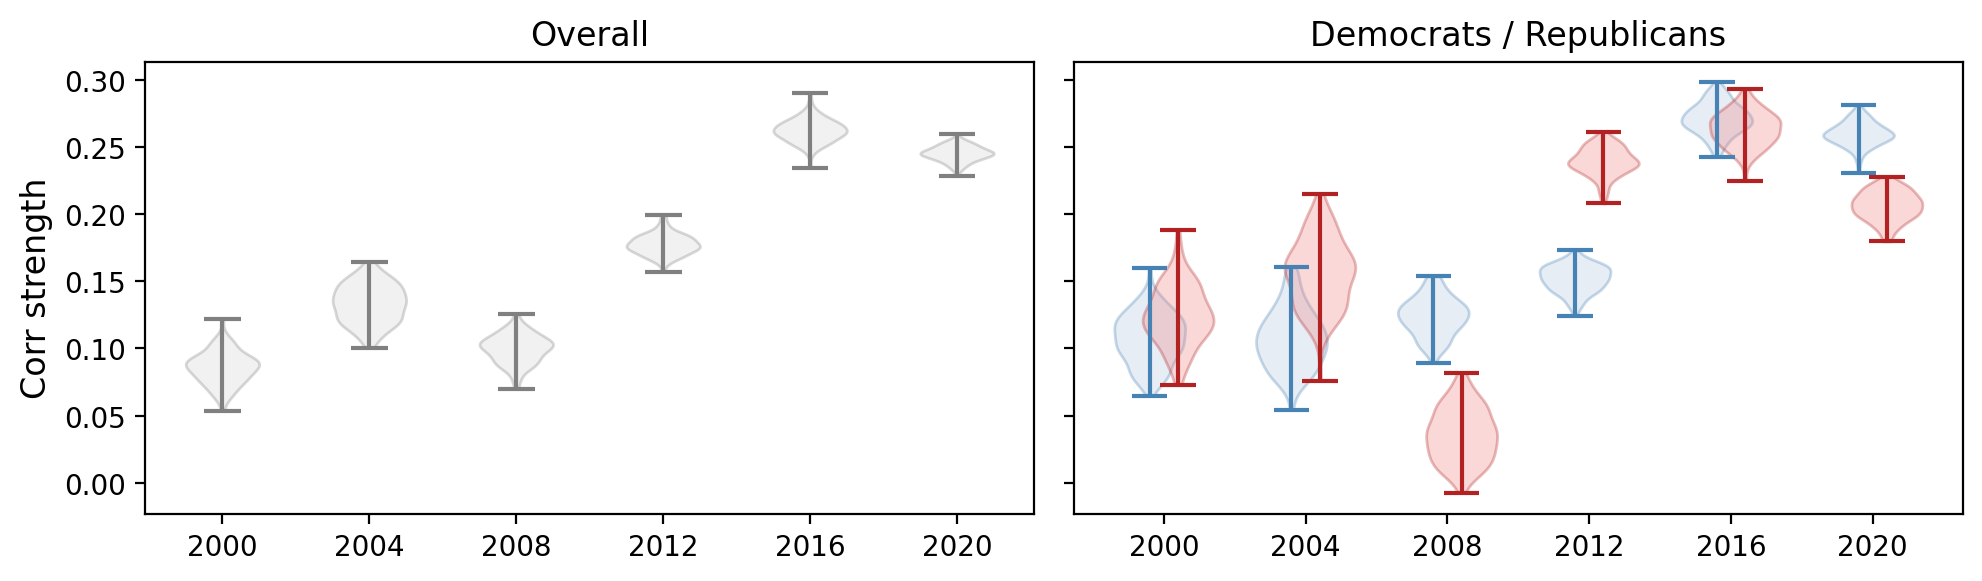

In [123]:
fig,ax = plt.subplots(ncols=2, figsize=(10,3), sharey=True)
vp = ax[0].violinplot(all_bts.values())
dem_vp = ax[1].violinplot(dem_bts.values(), positions=np.arange(1,7)-.1)
rep_vp = ax[1].violinplot(rep_bts.values(), positions=np.arange(1,7)+.1)
for pc in vp["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("grey")
for elem in ("cbars","cmins","cmaxes"):
    vp[elem].set_edgecolor("grey")

for pc in rep_vp["bodies"]:
    pc.set_facecolor("lightcoral")
    pc.set_edgecolor("firebrick")
for elem in ("cbars","cmins","cmaxes"):
    rep_vp[elem].set_edgecolor("firebrick")

for pc in dem_vp["bodies"]:
    pc.set_facecolor("lightsteelblue")
    pc.set_edgecolor("steelblue")
for elem in ("cbars","cmins","cmaxes"):
    dem_vp[elem].set_edgecolor("steelblue")

ax[0].set_title("Overall", fontsize=12)
ax[1].set_title("Democrats / Republicans", fontsize=12)
ax[0].set_ylabel("Corr strength", fontsize=12)

for i in [0,1]:
    ax[i].set_xticks(range(1,7), YEARS)
plt.tight_layout()
plt.savefig(OUTPATH + "sort_affp_corr_2000_2020_overall_partisan.png", dpi=300, bbox_inches="tight")

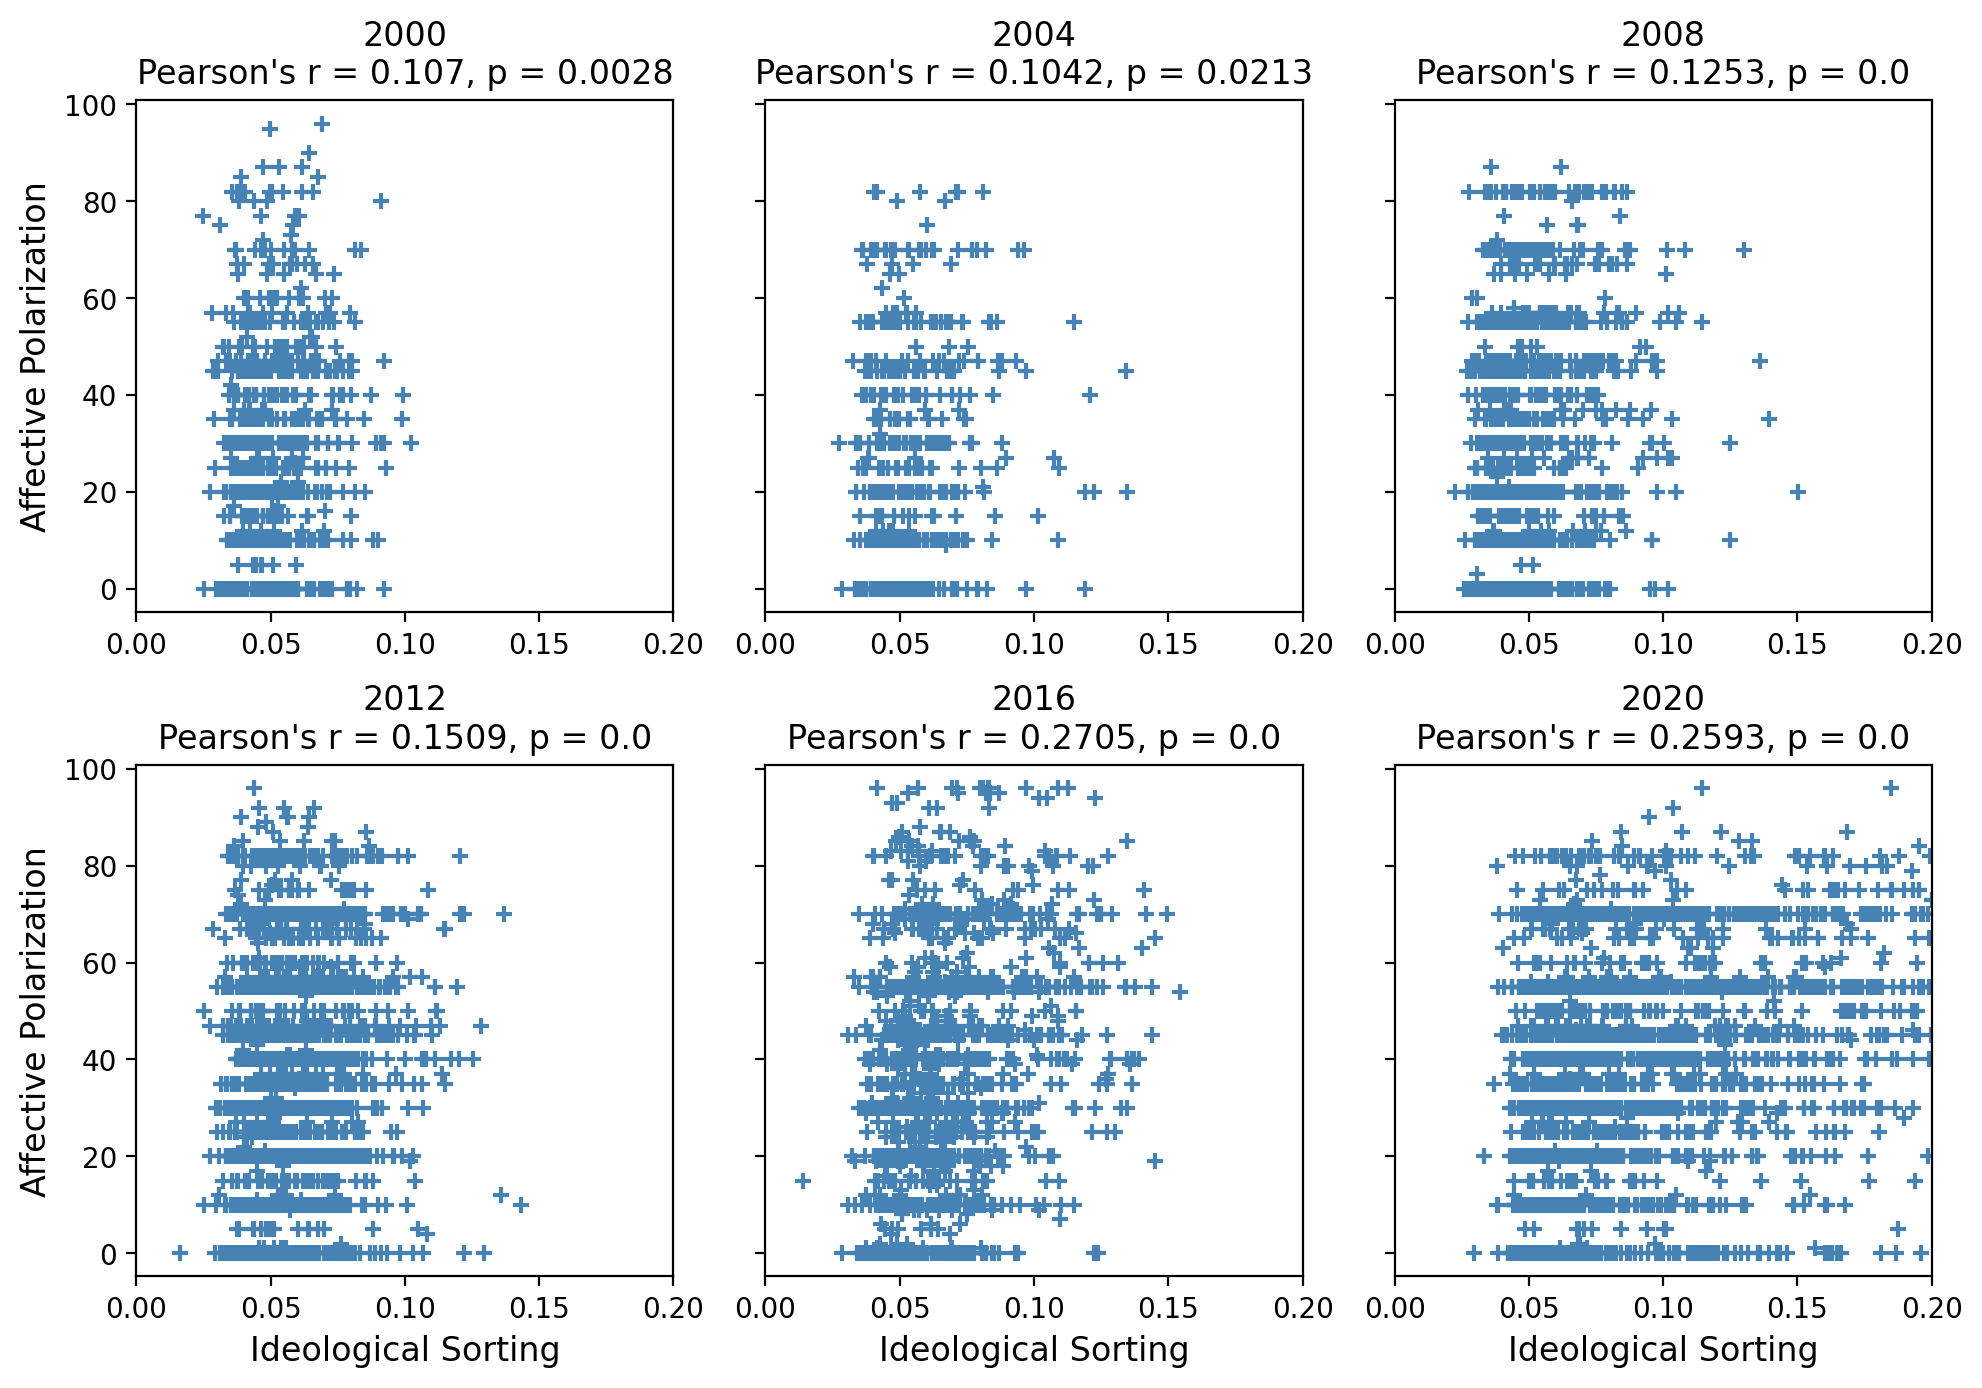

In [126]:
from scipy.stats import pearsonr
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,7), sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    rdf = respondent_df_all[respondent_df_all["year"]==year]
    rdf = rdf[rdf["part"]==-1]
    ax[i].scatter(rdf["sort"], rdf["affp"], marker="+", color="steelblue")
    # ax[i].hist2d(rdf["sort"], rdf["affp"], bins=[np.arange(0, .225, .0125), np.arange(0, 100, 8)])
    r,p = pearsonr(rdf["sort"], rdf["affp"])
    ax[i].set_xlim(0,0.20)
    ax[i].set_title(f"{year}\nPearson's r = {round(r,4)}, p = {round(p,4)}", fontsize=12)
    if i in [0,3]:
        ax[i].set_ylabel("Affective Polarization", fontsize=12)
    if i > 2:
        ax[i].set_xlabel("Ideological Sorting", fontsize=12)
plt.tight_layout()
# plt.savefig(OUTPATH + "sort_affp_hist2d_2000_2020.png", dpi=300, bbox_inches="tight")

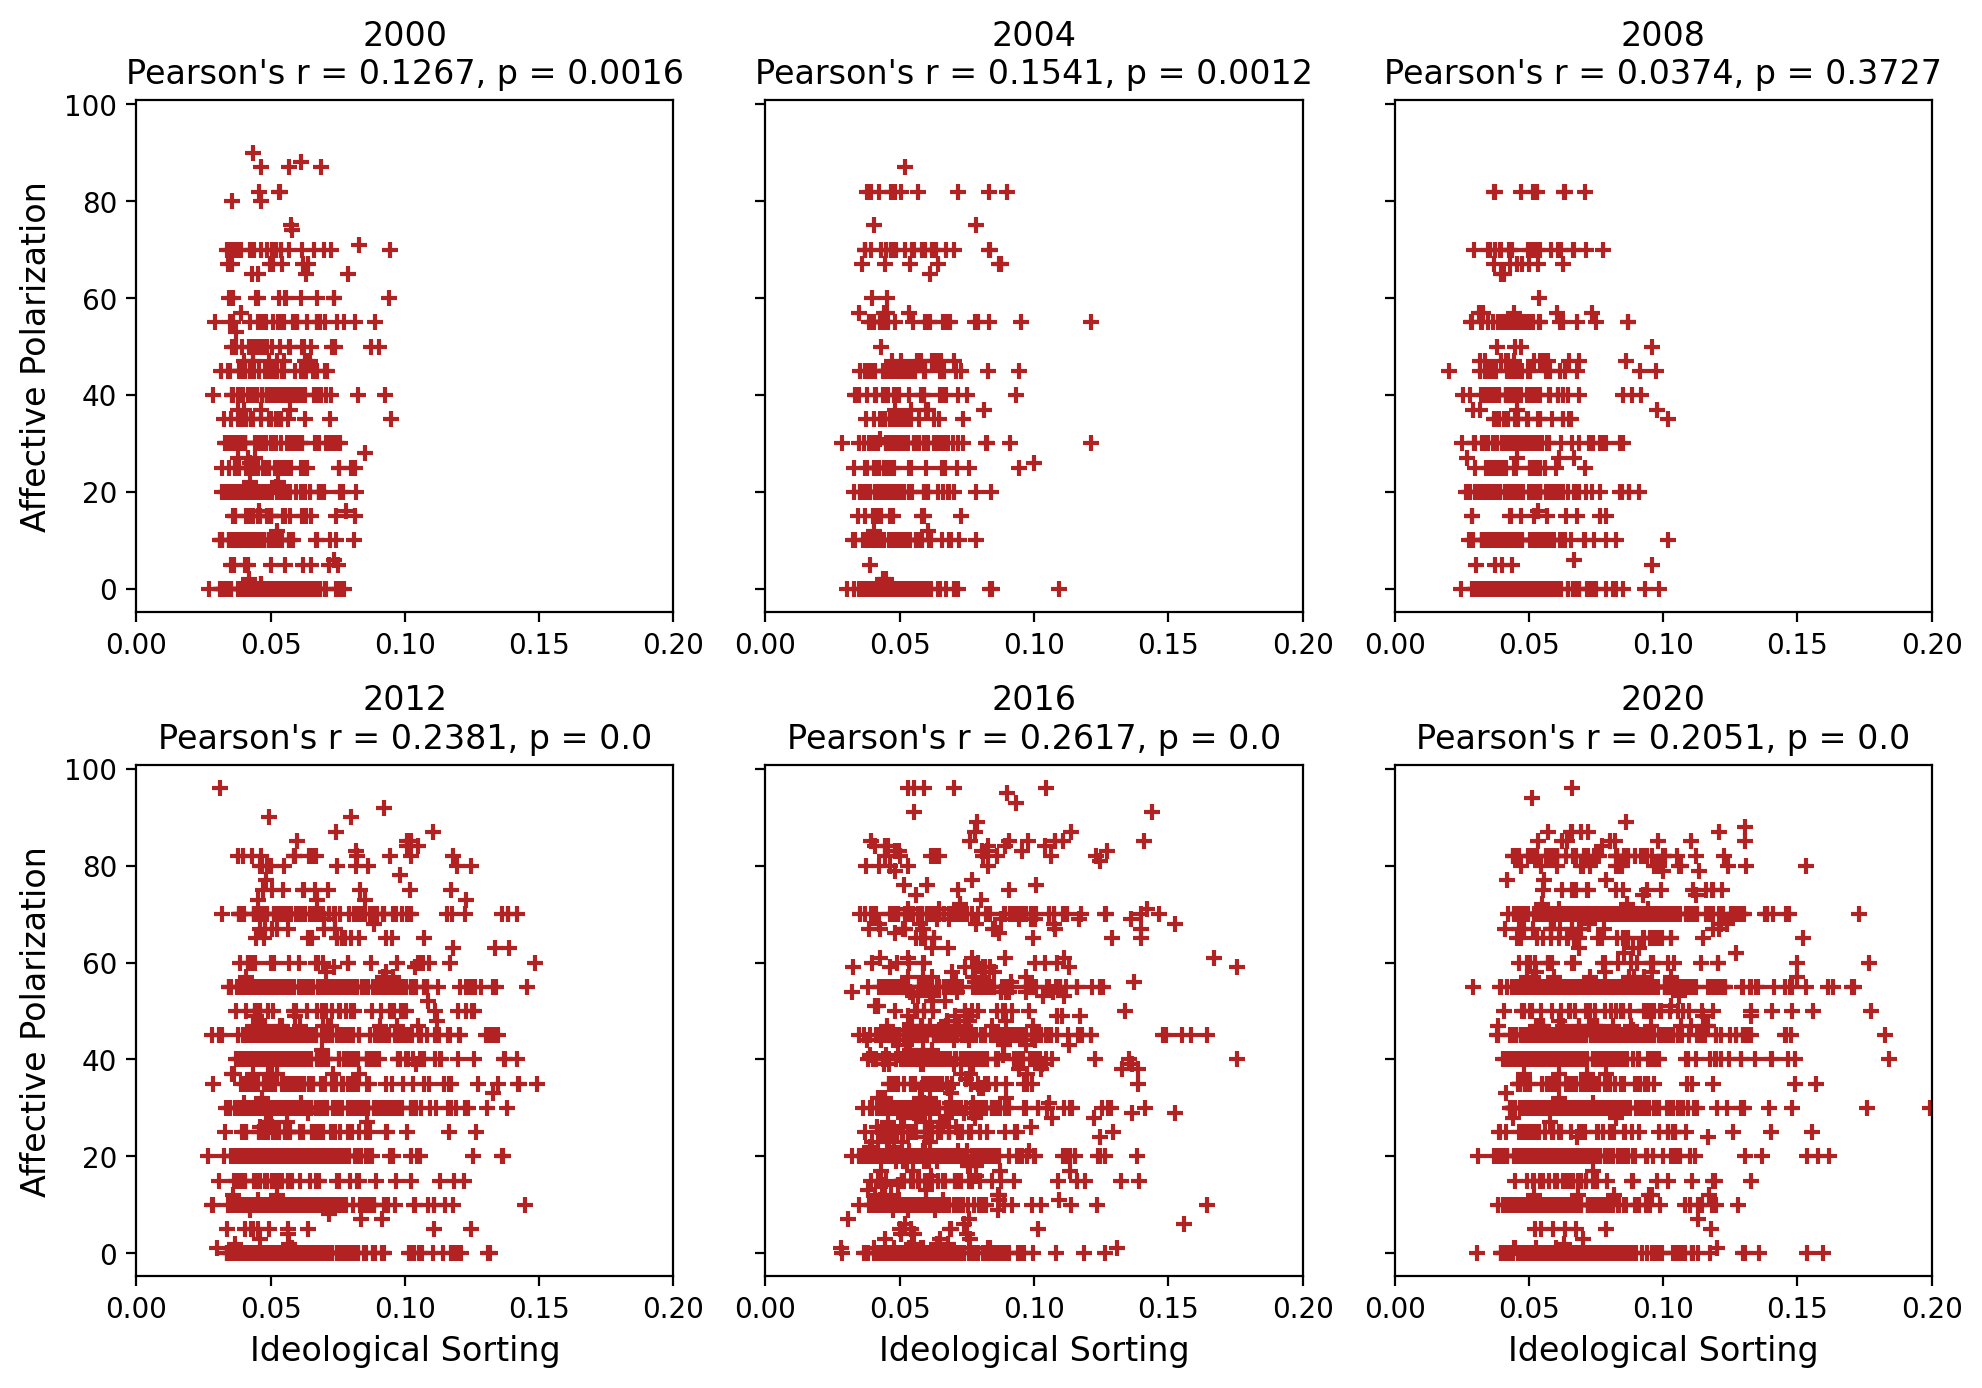

In [127]:
from scipy.stats import pearsonr
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,7), sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    rdf = respondent_df_all[respondent_df_all["year"]==year]
    rdf = rdf[rdf["part"]==1]
    ax[i].scatter(rdf["sort"], rdf["affp"], marker="+", color="firebrick")
    # ax[i].hist2d(rdf["sort"], rdf["affp"], bins=[np.arange(0, .225, .0125), np.arange(0, 100, 8)])
    r,p = pearsonr(rdf["sort"], rdf["affp"])
    ax[i].set_xlim(0,0.20)
    ax[i].set_title(f"{year}\nPearson's r = {round(r,4)}, p = {round(p,4)}", fontsize=12)
    if i in [0,3]:
        ax[i].set_ylabel("Affective Polarization", fontsize=12)
    if i > 2:
        ax[i].set_xlabel("Ideological Sorting", fontsize=12)
plt.tight_layout()
# plt.savefig(OUTPATH + "sort_affp_hist2d_2000_2020.png", dpi=300, bbox_inches="tight")

## misc

In [ ]:
# respondent_df_all_filter = respondent_df_all[respondent_df_all["part"]!=0].copy()
# PARTY_LABEL = {-1:"DEM", 1:"REP"}
# respondent_df_all_filter["partisan"] = respondent_df_all_filter["part"].map(lambda x: PARTY_LABEL[x])
# colors = ["#D95F59", "#5B99C2"]

# fig,ax = plt.subplots(figsize=(8,3))
# ax.set_xticks(range(1,7), YEARS)
# sns.violinplot(
#     x="year", y="affp", hue="partisan", 
#     data=respondent_df_all_filter, palette=colors, ax=ax)
# ax.set_xlabel("")
# ax.set_ylabel("Affective Polarization", fontsize=12)
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# # plt.savefig(OUTPATH + "affp_years.png", dpi=300, bbox_inches="tight")